# Building Position within the Urban Block

`footprint_attributes.position` classifies each footprint into one of five
relative-position categories using a contact-force analogy: a virtual unit
pressure is applied along every shared wall segment between touching
buildings, and the resultant force, confinement ratio, and weighted angle
decide the class.

| class | meaning |
|---|---|
| `isolated` | no touching neighbours |
| `lateral` | touches on one side |
| `corner` | touches on two perpendicular sides |
| `confined` | touches on both lateral sides |
| `torque` | confined/corner with high angular acceleration |

This notebook first shows how the classifier behaves on idealized
configurations with a known-by-construction answer, then runs it on the
three real pilot-area datasets.

## Setup

In [1]:
import sys
sys.path.insert(0, "../tests")  # so `import shapes` finds tests/shapes.py

import geopandas as gpd
import matplotlib.pyplot as plt

from footprint_attributes import position
from shapes import (
    isolated_building_gdf, lateral_pair_gdf, corner_triplet_gdf,
    confined_quartet_gdf, torque_triplet_gdf,
)


## Part 1 — Theory on idealized configurations

Five synthetic scenarios, one per relative-position class. In each, the
building of interest is row 0 (the centre/main building).

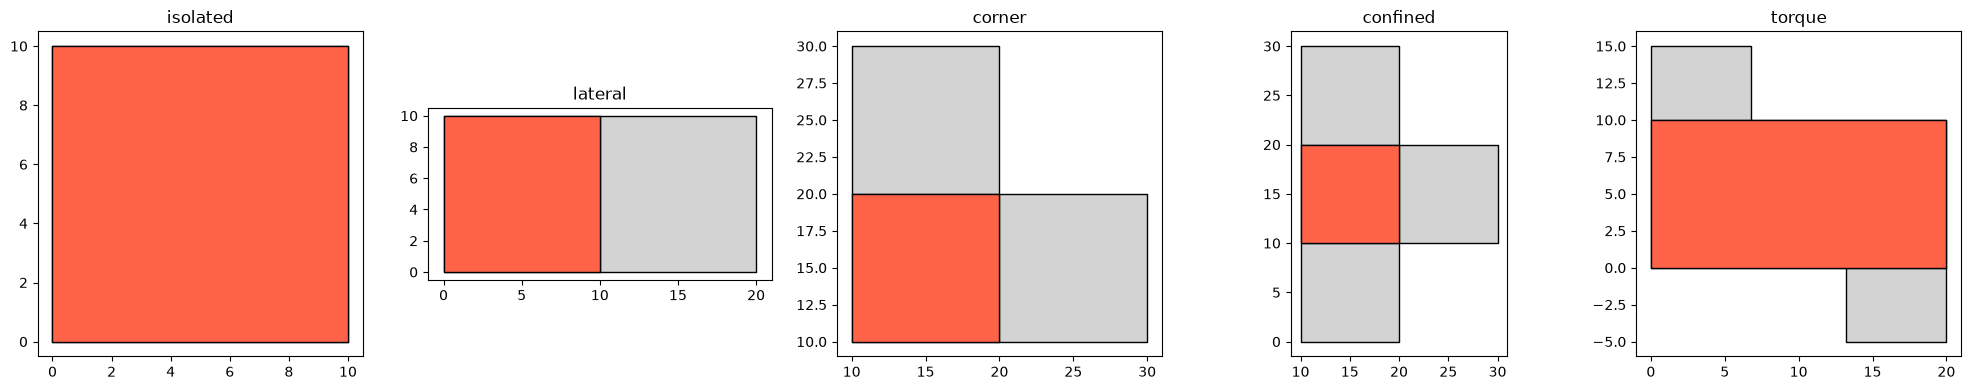

In [2]:
scenarios = {
    "isolated": isolated_building_gdf(),
    "lateral": lateral_pair_gdf(),
    "corner": corner_triplet_gdf(),
    "confined": confined_quartet_gdf(),
    "torque": torque_triplet_gdf(),
}

fig, axes = plt.subplots(1, len(scenarios), figsize=(4 * len(scenarios), 4))
for ax, (name, gdf) in zip(axes, scenarios.items()):
    gdf.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
    gdf.iloc[[0]].plot(ax=ax, facecolor="tomato", edgecolor="black")
    ax.set_title(name)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Classify each scenario and check it matches its name

If the classifier is working correctly, `relativePosition` for row 0
(the highlighted building) should equal the scenario's name.

In [3]:
for name, gdf in scenarios.items():
    result = position(gdf)
    got = result["relativePosition"].iloc[0]
    print(f"{name:10s} -> relativePosition={got:10s}  "
          f"force={result['contact_force'].iloc[0]:.3f}  "
          f"confinement={result['contact_confinementRatio'].iloc[0]:.3f}  "
          f"angularAcc={result['contact_angularAcc'].iloc[0]:.3f}")


isolated   -> relativePosition=isolated    force=0.000  confinement=0.000  angularAcc=0.000
lateral    -> relativePosition=lateral     force=1.000  confinement=0.000  angularAcc=0.000
corner     -> relativePosition=corner      force=1.414  confinement=0.293  angularAcc=0.000
confined   -> relativePosition=confined    force=1.000  confinement=0.667  angularAcc=0.000
torque     -> relativePosition=torque      force=0.000  confinement=1.000  angularAcc=2.154


### Full pipeline vs. classification-only

`position(gdf, ...)` runs the full pipeline (computes contact-force
columns *and* classifies). `position.relative_position(gdf, ...)`
classifies only — it reuses the `contact_*` columns if already present
(fast path), or recomputes them from geometry otherwise.

In [4]:
full = position(scenarios["lateral"], buffer=0.1)
labels_fast = position.relative_position(full)          # reuses columns
labels_slow = position.relative_position(scenarios["lateral"])  # from geometry
print("fast path:", labels_fast)
print("slow path:", labels_slow)


fast path: ['lateral', 'lateral']
slow path: ['lateral', 'lateral']


## Part 2 — Real data: the three pilot areas

Same classification, run on the actual digitised footprints from San José
(Costa Rica), Guatemala City, and Santo Domingo (Dominican Republic).

In [5]:
CITY_FILES = {
    "san_jose": "data/san_jose_pilot_region.gpkg",
    "guatemala": "data/guatemala_pilot_region.gpkg",
    "santo_domingo": "data/santo_domingo_pilot_region.gpkg",
}

def load_city(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].reset_index(drop=True)
    if (gdf.geometry.type == "MultiPolygon").any():
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    gdf.geometry = gdf.geometry.make_valid()
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    return gdf


In [6]:
colors = {"isolated": "#1f77b4", "lateral": "#ff7f0e", "corner": "#2ca02c",
          "confined": "#d62728", "torque": "#9467bd"}

results = {}
for city, path in CITY_FILES.items():
    gdf = load_city(path)
    gdf = position(gdf, buffer=0.1, height_column="height")
    results[city] = gdf
    print(f"--- {city} ---")
    print(gdf["relativePosition"].value_counts())


--- san_jose ---
relativePosition
isolated    540
lateral     253
torque       64
confined     53
corner        1
Name: count, dtype: int64


--- guatemala ---
relativePosition
isolated    184
lateral     132
torque       69
confined     41
corner        9
Name: count, dtype: int64


--- santo_domingo ---
relativePosition
isolated    1358
lateral       91
torque         8
corner         3
confined       3
Name: count, dtype: int64


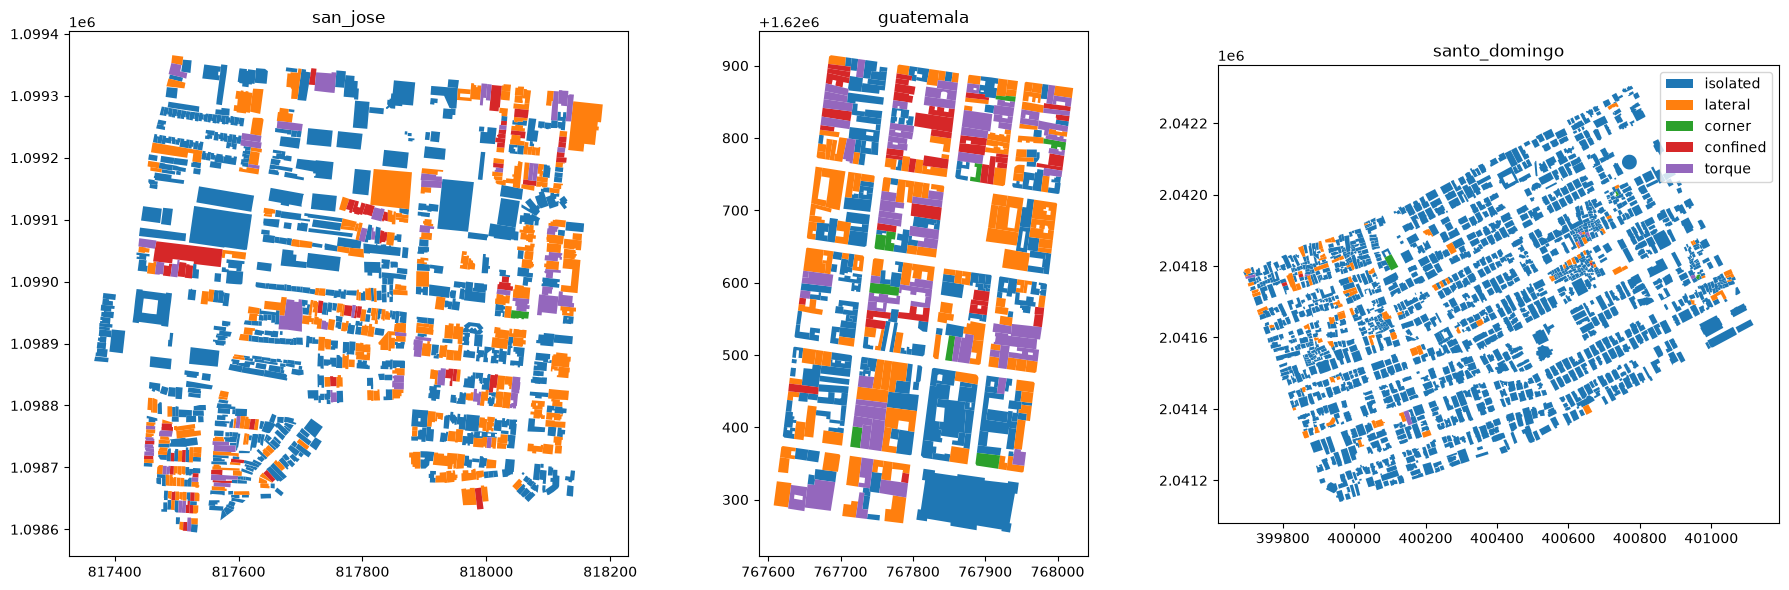

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (city, gdf) in zip(axes, results.items()):
    for cls, color in colors.items():
        subset = gdf[gdf["relativePosition"] == cls]
        if len(subset):
            subset.plot(ax=ax, color=color, label=cls)
    ax.set_title(city)
axes[-1].legend()
plt.tight_layout()
plt.show()


## Result

One GeoDataFrame per city, each carrying the position attributes.
Suggested columns to visualise on a map:

- `relativePosition` — categorical class (color by category)
- `contact_force`, `contact_confinementRatio` — underlying continuous metrics


In [8]:
san_jose_gdf = results["san_jose"]
guatemala_gdf = results["guatemala"]
santo_domingo_gdf = results["santo_domingo"]

map_columns = [
    "id", "relativePosition", "contact_force", "contact_confinementRatio",
    "contact_angularAcc", "geometry",
]
san_jose_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,contact_force,contact_confinementRatio,contact_angularAcc,contact_angle,relativePosition
0,1000009.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((817592.282 1098630.841, 817583.141 1...",0.000000,0.000000,0.000000,0.000000,isolated
1,1219.0,san_jose,6.0,2.0,1975,pre_code,M,M,metallic,"POLYGON ((817554.533 1098638.188, 817559.35 10...",0.000000,0.000000,0.000000,0.000000,isolated
2,1000010.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817593.338 1098634.876, 817591.389 1...",0.000000,0.000000,0.000000,0.000000,isolated
3,1221.0,san_jose,6.0,2.0,1985,low_code,M,M,bright_concrete,"POLYGON ((817509.464 1098646.298, 817509.417 1...",3.026685,0.837137,6.652848,2.630243,torque
4,1222.0,san_jose,6.0,2.0,1988,medium_code,M,M,metallic,"POLYGON ((817484.519 1098643.546, 817484.505 1...",0.000000,0.000000,0.000000,0.000000,isolated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,1000029.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((817487.513 1099327.718, 817489.214 1...",0.000000,0.000000,0.000000,0.000000,isolated
907,1000030.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817491.914 1098875.344, 817490.37 10...",0.000000,0.000000,0.000000,0.000000,isolated
908,1000031.0,san_jose,NaN,NaN,1985,low_code,NaN,NaN,metallic,"POLYGON ((817594.418 1098785.886, 817594.699 1...",0.000000,0.000000,0.000000,0.000000,isolated
909,1000032.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817661.05 1098730.134, 817658.341 10...",0.000000,0.000000,0.000000,0.000000,isolated


In [9]:
guatemala_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,contact_force,contact_confinementRatio,contact_angularAcc,contact_angle,relativePosition
0,7,guatemala,21.0,7.0,1985,pre_code,CR,CR,metallic,"POLYGON ((767790.902 1620302.842, 767786.491 1...",13.808249,0.000000,3.179489,0.000000,lateral
1,8,guatemala,6.0,2.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((767692.792 1620324.14, 767686.494 16...",15.985263,0.158624,3.681147,0.948898,torque
2,9,guatemala,18.0,6.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((767653.981 1620317.212, 767650.617 1...",2.058260,0.949834,3.536369,2.984542,torque
3,10,guatemala,9.0,3.0,1985,pre_code,CR,CR,dark_shadow,"POLYGON ((767631.691 1620320.309, 767627.553 1...",10.787892,0.000000,2.782281,0.000000,lateral
4,53,guatemala,3.0,1.0,1985,pre_code,M,M,bright_concrete,"POLYGON ((767736.621 1620273.206, 767737.434 1...",0.000000,0.000000,0.000000,0.000000,isolated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,1000020,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767967.054 1620766.917, 767967.159 1...",0.000000,0.000000,0.000000,0.000000,isolated
431,1000021,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767957.402 1620784.045, 767971.325 1...",0.000000,0.000000,0.000000,0.000000,isolated
432,1000024,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767742.538 1620785.376, 767743.107 1...",0.000000,0.000000,0.000000,0.000000,isolated
433,1000001,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767743.478 1620338.287, 767750.941 1...",0.000000,0.000000,0.000000,0.000000,isolated


In [10]:
santo_domingo_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,contact_force,contact_confinementRatio,contact_angularAcc,contact_angle,relativePosition
0,756,santo_domingo,6.0,2.0,1985,low_code,M,M,metallic,"POLYGON ((400755.503 2041946.512, 400763.567 2...",0.000000,0.0,0.000000,0.000000e+00,isolated
1,1448,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((400752.768 2041786.239, 400747.871 2...",2.337443,0.0,0.292902,9.884312e-08,lateral
2,783,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((400728.96 2042022.949, 400740.02 204...",5.039558,0.0,3.433575,5.161914e-08,lateral
3,506,santo_domingo,9.0,3.0,1985,low_code,M,M,metallic,"POLYGON ((400621.845 2042180.408, 400624.684 2...",0.000000,0.0,0.000000,0.000000e+00,isolated
4,952,santo_domingo,27.0,9.0,1985,low_code,CR,CR,asphalt,"POLYGON ((399942.413 2041384.087, 399943.943 2...",0.000000,0.0,0.000000,0.000000e+00,isolated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,411,santo_domingo,NaN,NaN,1985,low_code,NaN,NaN,NaN,"POLYGON ((400660.873 2042109.183, 400673.948 2...",0.000000,0.0,0.000000,0.000000e+00,isolated
1459,410,santo_domingo,9.0,3.0,1985,low_code,M,M,NaN,"POLYGON ((400662.197 2042101.872, 400655.932 2...",0.000000,0.0,0.000000,0.000000e+00,isolated
1460,409,santo_domingo,12.0,4.0,1989,low_code,M,M,NaN,"POLYGON ((400685.397 2042099.449, 400695.452 2...",0.000000,0.0,0.000000,0.000000e+00,isolated
1461,408,santo_domingo,15.0,5.0,1985,low_code,M,M,NaN,"POLYGON ((400698.257 2042029.509, 400694.637 2...",0.000000,0.0,0.000000,0.000000e+00,isolated


In [11]:
map_columns


['id',
 'relativePosition',
 'contact_force',
 'contact_confinementRatio',
 'contact_angularAcc',
 'geometry']